In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import seaborn as sns

In [2]:
df_reviews =  pd.read_csv('data/reviews_nuevo.csv', encoding="UTF-8")
df_app_dev = pd.read_csv('data/application_developers.csv', encoding="UTF-8")
df_applications =  pd.read_csv('data/applications.csv', encoding="UTF-8")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20200\952631844.py:3: DtypeWarning: Columns (0: required_age) have mixed types. Specify dtype option on import or set low_memory=False.
  df_applications =  pd.read_csv('data/applications.csv', encoding="UTF-8")


## Preprocesamiento 

In [3]:
df_reviews.rename(columns={'app_id': 'appid'}, inplace=True)

df_reviews = df_reviews.groupby('appid').agg(
    total_reviews=('appid', 'count'),
    avg_score=('review_score', 'mean'),
).reset_index()

df_merged = pd.merge(df_applications, df_app_dev, on='appid', how='inner')

df_merged = pd.merge(df_merged, df_reviews, on='appid', how='inner')

df_devs = df_merged.groupby('developer_id').agg(
    total_games=('appid', 'count'),
    avg_score_total=('avg_score', 'mean'),
    total_reviews=('total_reviews', 'sum') 
).reset_index()

X = df_devs[['total_games', 'avg_score_total', 'total_reviews']]

X['total_games'] = np.log1p(X['total_games'])
X['total_reviews'] = np.log1p(X['total_reviews'])

X_scaled = StandardScaler().fit_transform(X)

## **K-Means**

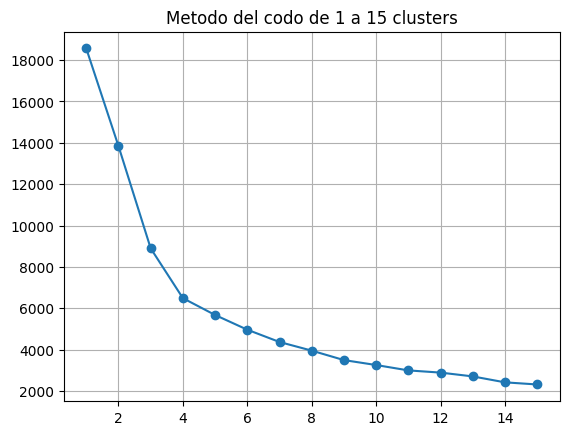

In [4]:
from sklearn.cluster import KMeans
sse = []

clusters = list(range(1, 16))
for k in clusters:
    kmeans = KMeans(n_clusters=k).fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.plot(clusters, sse, marker="o")
plt.title("Metodo del codo de 1 a 15 clusters")
plt.grid(True)
plt.show()

In [5]:
kmeans_3 = KMeans(n_clusters=3, random_state=0).fit(X_scaled)

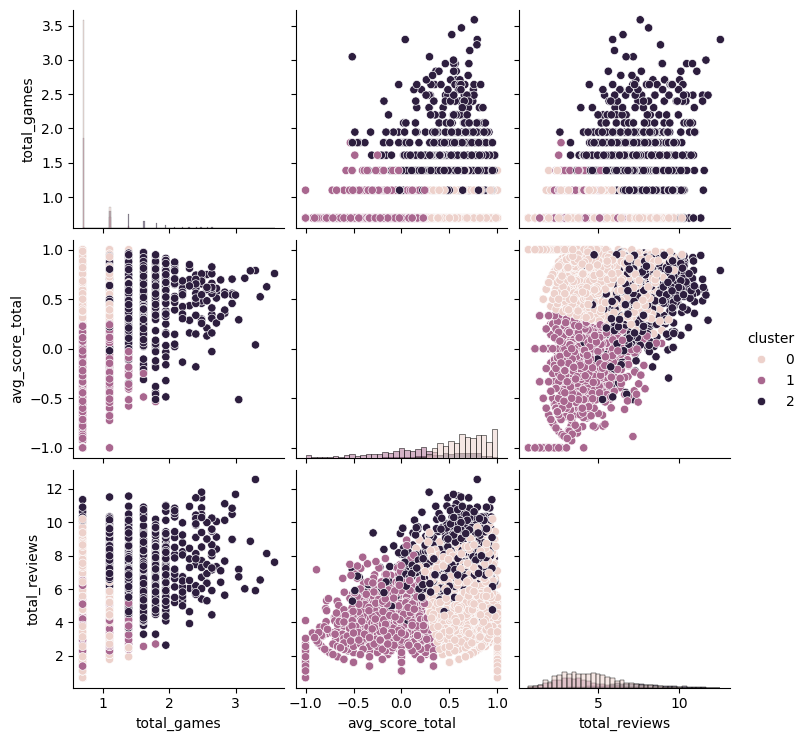

In [6]:
df_plot = X.copy()
df_plot['cluster'] = kmeans_3.labels_
sns.pairplot(df_plot, hue='cluster', diag_kind='hist')

In [7]:
kmeans_4 = KMeans(n_clusters=4, random_state=0).fit(X_scaled)

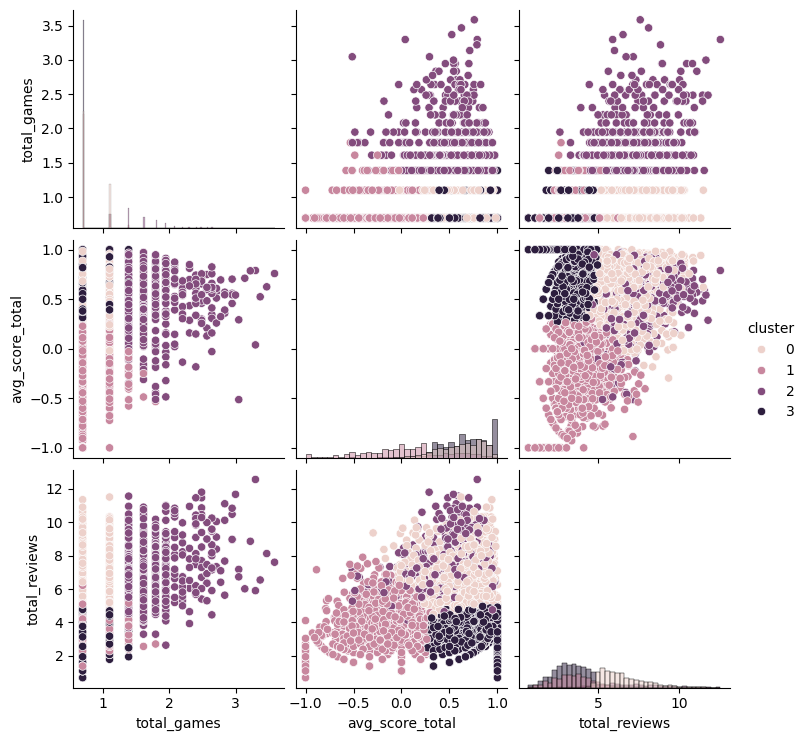

In [8]:
df_plot = X.copy()
df_plot['cluster'] = kmeans_4.labels_
sns.pairplot(df_plot, hue='cluster', diag_kind='hist')

## **Clustering Jerárquico**

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage
cluster_ward = linkage(X_scaled, 'ward')

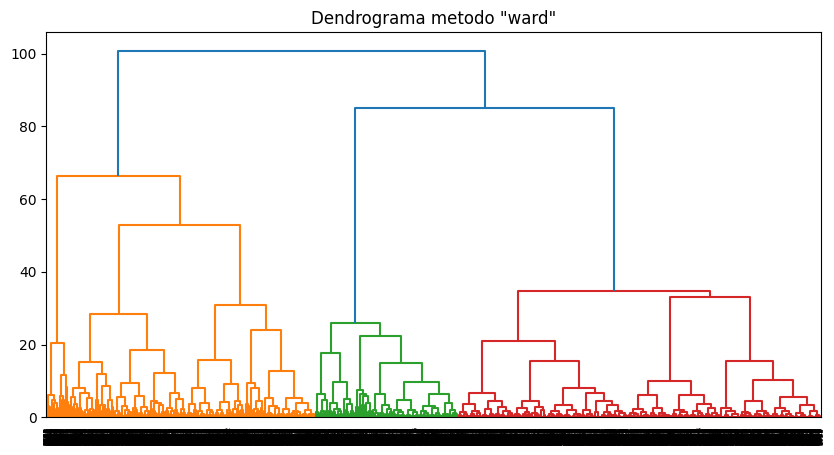

In [10]:
fig = plt.figure(figsize=(10, 5))
dendrogram(cluster_ward)
plt.title('Dendrograma metodo "ward"')
plt.show()

In [11]:
from sklearn.cluster import AgglomerativeClustering
ward = AgglomerativeClustering(n_clusters=None,
                                 linkage="ward",
                                 distance_threshold=70).fit(X_scaled)

print("Número de clusters: ", ward.n_clusters_)

Número de clusters:  3


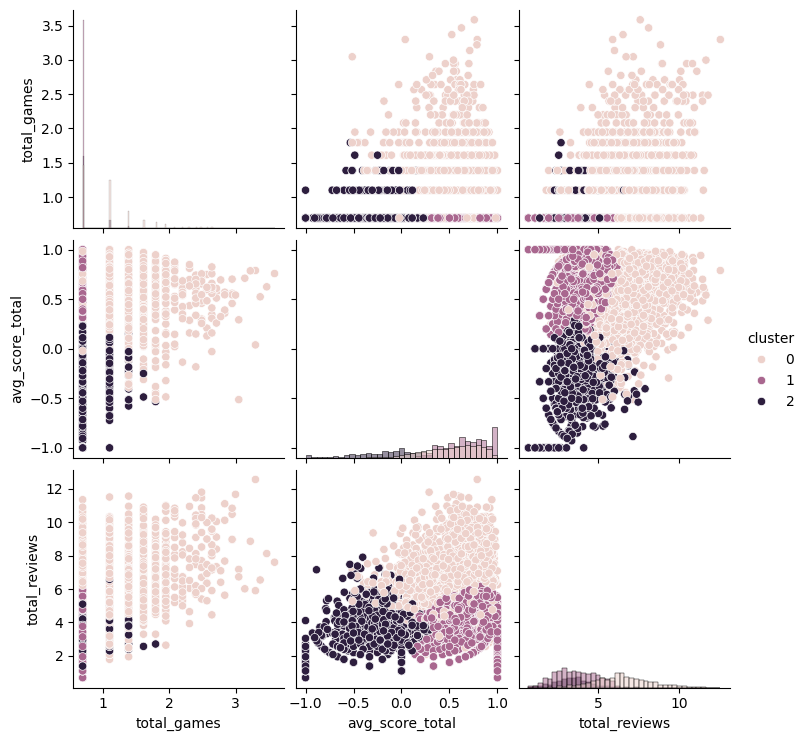

In [12]:
df_plot = X.copy()
df_plot['cluster'] = ward.labels_
sns.pairplot(df_plot, hue='cluster', diag_kind='hist')

## Evaluación

In [13]:
print("K-Means k = 3\t", silhouette_score(X_scaled, kmeans_3.labels_))
print("K-Means k = 4\t", silhouette_score(X_scaled, kmeans_4.labels_))
print("Ward \t", silhouette_score(X_scaled, ward.labels_))

K-Means k = 3	 0.3579798100337617
K-Means k = 4	 0.35504268000074224
Ward 	 0.3189364778732757


In [14]:
from sklearn.metrics.pairwise import cosine_similarity
def sim_matrix(features, model):
    labels = model.labels_
    useful_labels = labels >= 0

    indices = np.argsort(labels[useful_labels])
    sorted_features = features[useful_labels][indices]

    d = cosine_similarity(sorted_features, sorted_features)

    plt.figure(figsize=(8, 8))
    im = plt.imshow(d, cmap='plasma', vmin=0.0, vmax=1.0)
    plt.title(f"{model.__class__.__name__}")
    plt.colorbar(im)
    plt.show()

### K-Means con k = 3

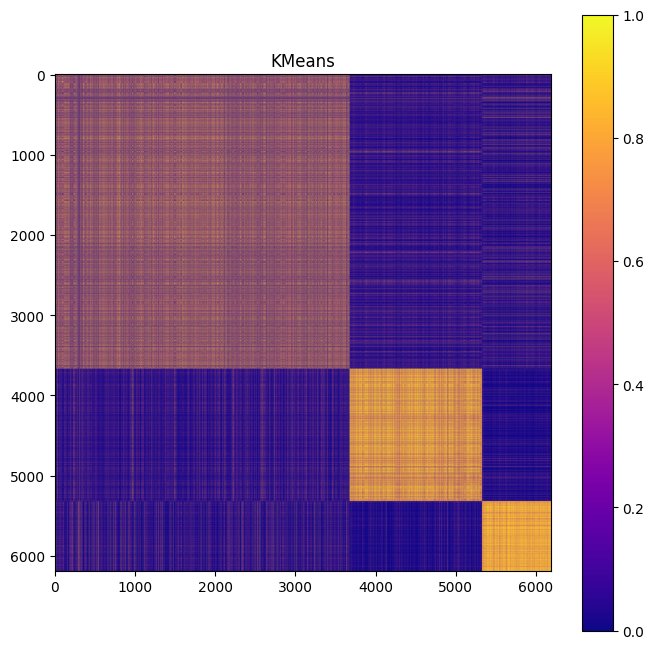

In [15]:
sim_matrix(X_scaled, kmeans_3)

### K-Means con k = 4

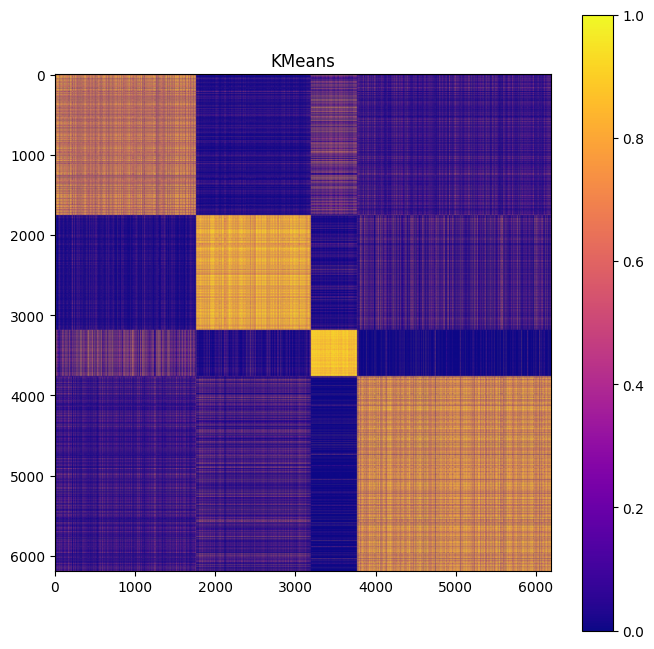

In [16]:
sim_matrix(X_scaled, kmeans_4)

### Clustering jerarquico metodo ward

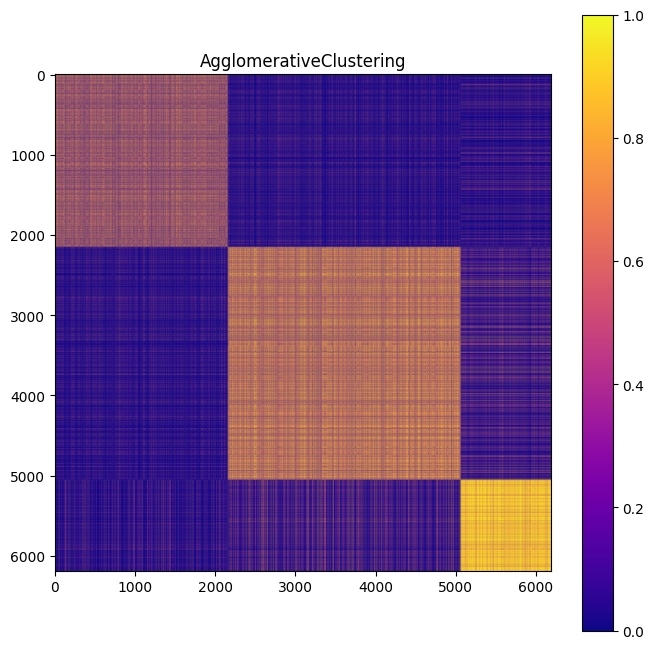

In [17]:
sim_matrix(X_scaled, ward)